# Kernel Ridge Regression
**Definición:**
Dados $\{(\mathbf{x}_i, y_i)\}_{i=1}^n$, el problema de Kernel Ridge Regression (KRR) consiste en resolver:
$$
\min_{f \in \mathcal{H}_{\mathcal{K}}} \sum_{i=1}^n (y_i - f(\mathbf{x}_i))^2 + \lambda \|f\|_{\mathcal{H}_{\mathcal{K}}}^2
$$
donde  $\mathcal{H}_{\mathcal{K}}$ es un espacio de Hilbert con núcleo repoductor $\mathcal{K}$.

El teorema del representador permite escribir $f(\mathbf{x}) = \sum_{j=1}^n \alpha_j \mathcal{K}(\mathbf{x}, \mathbf{x}_j)$, y

*   Pérdida: $\sum_{i=1}^n \left(y_i - \sum_{j=1}^n \alpha_j \mathcal{K}(\mathbf{x}_i, \mathbf{x}_j)\right)^2$
*   Norma:  $\|f\|_{\mathcal{H}}^2 = \sum_{i,j=1}^n \alpha_i \alpha_j \mathcal{K}(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{\alpha}^T \mathbf{K} \mathbf{\alpha}
$

donde $\mathbf{K}_{ij} = \mathcal{K}(\mathbf{x}_i, \mathbf{x}_j)$ es la $\textbf{matriz de Gram}$.

**Solución en Forma Cerrada**:
El problema KRR tiene solución única dada por:
$$
\mathbf{\alpha}^* = (\mathbf{K} + \lambda \mathbf{I}_n)^{-1} \mathbf{y}
$$
y la función predictora es:
$$
\hat{f}(\mathbf{x}) = \sum_{i=1}^n \alpha_i^* \mathbf{K}(\mathbf{x}, \mathbf{x}_i) = \mathbf{k}(\mathbf{x})^T (\mathbf{K} + \lambda \mathbf{I})^{-1} \mathbf{y}
$$
donde $\mathbf{k}(\mathbf{x}) = [\mathbf{K}(\mathbf{x}, \mathbf{x}_1), \ldots, \mathbf{K}(\mathbf{x}, \mathbf{x}_n)]^T$.


In [1]:
import sys
import time
import pandas as pd
import numpy as np
from numpy import genfromtxt
from numpy.linalg import *
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import *
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


np.set_printoptions(precision=4)
np.set_printoptions(threshold=30)
np.set_printoptions(linewidth=300)
np.set_printoptions(threshold=sys.maxsize)

## Implementacion del KRR

In [2]:
class KernelRidgeRegression:
    """
    Parámetros:
    -----------
    alpha : float
        Parámetro de regularización (lambda)
    kernel : str
        Tipo de kernel: 'rbf', 'linear', 'polynomial'
    gamma : float
        Parámetro para kernel RBF
    degree : int
        Grado para kernel polinomial
    coef0 : float
        Término independiente para kernel polinomial
    """

    def __init__(self, alpha=1.0, kernel='rbf', gamma=0.1, degree=3, coef0=1.0):
        self.alpha = alpha
        self.kernel = kernel
        self.gamma = gamma
        self.degree = degree
        self.coef0 = coef0
        self.X_train = None
        self.alpha_dual = None  # Coeficientes duales

    def _compute_kernel(self, X1, X2):
        """
        Calcula la matriz de kernel entre dos conjuntos de datos

        Parámetros:
        -----------
        X1 : array-like, shape (n_samples1, n_features)
        X2 : array-like, shape (n_samples2, n_features)

        Retorna:
        --------
        K : array-like, shape (n_samples1, n_samples2)
        """
        n1, n2 = X1.shape[0], X2.shape[0]

        if self.kernel == 'linear':
            # Kernel lineal: K(x, y) = x^T y
            K = np.dot(X1, X2.T)

        elif self.kernel == 'rbf':
            # Kernel RBF (Gaussiano): K(x, y) = exp(-gamma * ||x - y||^2)
            # Calculamos las normas al cuadrado
            X1_squared = np.sum(X1**2, axis=1).reshape(-1, 1)
            X2_squared = np.sum(X2**2, axis=1).reshape(1, -1)
            distances_squared = X1_squared + X2_squared - 2 * np.dot(X1, X2.T)
            K = np.exp(-self.gamma * distances_squared)

        elif self.kernel == 'polynomial':
            # Kernel polinomial: K(x, y) = (gamma * x^T y + coef0)^degree
            K = (self.gamma * np.dot(X1, X2.T) + self.coef0) ** self.degree

        else:
            raise ValueError(f"Kernel '{self.kernel}' no soportado")

        return K

    def fit(self, X, y):
        """
        Entrena el modelo Kernel Ridge Regression

        Solución: α = (K + αI)⁻¹ y

        donde:
        - K es la matriz de kernel entre muestras de entrenamiento
        - α es el parámetro de regularización
        - y son los valores objetivo
        """
        self.X_train = X.copy()
        n_samples = X.shape[0]

        # Calcular matriz de kernel entre muestras de entrenamiento
        print(f"Calculando matriz de kernel ({n_samples}x{n_samples})...")
        start_time = time.time()
        K = self._compute_kernel(X, X)

        # Añadir regularización: K + αI
        K_reg = K + self.alpha * np.eye(n_samples)

        # Resolver el sistema lineal: (K + αI)α = y
        # α = (K + αI)⁻¹ y
        print("Resolviendo sistema lineal...")
        self.alpha_dual = np.linalg.solve(K_reg, y)

        elapsed_time = time.time() - start_time
        print(f"Entrenamiento completado en {elapsed_time:.2f} segundos")

        return self

    def predict(self, X):
        """
        Realiza predicciones para nuevos datos

        f(x) = Σ α_i * K(x_i, x)
        """
        if self.alpha_dual is None:
            raise RuntimeError("El modelo debe ser entrenado antes de predecir")

        # Calcular matriz de kernel entre entrenamiento y nuevos datos
        K_star = self._compute_kernel(self.X_train, X)

        # Predicción: f(x) = K_star^T * α
        predictions = np.dot(K_star.T, self.alpha_dual)

        return predictions

# Generacion de datos sinteticos

=== GENERANDO DATOS NO LINEALES ===


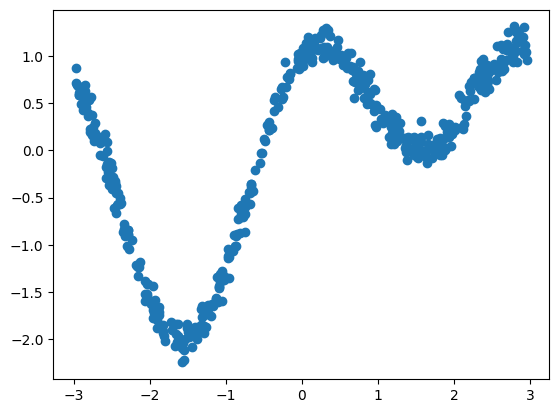

In [3]:
# Generar dataset no lineal para demostración
print("=== GENERANDO DATOS NO LINEALES ===")
np.random.seed(42)

# Opción 1: Datos sintéticos con relación no lineal
n_samples = 500
X = np.random.uniform(-3, 3, (n_samples, 1))
y = np.sin(X).ravel() + np.cos(2*X).ravel() + 0.1 * np.random.randn(n_samples)
plt.scatter(X,y)
# Agregar características polinómicas implícitas
#X = np.column_stack([X, X**2])  # Añadimos una característica cuadrática

# Convertir X a DataFrame
data = pd.DataFrame({
    'feature_1': X.ravel(),
    'feature_2': (X**2).ravel(),
    'y_value': y
})

X = data[['feature_1', 'feature_2']]
y = data['y_value']
# División entrenamiento/prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

# Entrenamiento y prueba del modelo

In [4]:
# Normalizar características
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1)).ravel()

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")
print(f"Número de características: {X.shape[1]}")

# Probar diferentes configuraciones de kernel
kernels = ['linear', 'polynomial', 'rbf']
custom_krr_results = {}

print("\n=== ENTRENANDO DIFERENTES KERNELS ===")
for kernel_type in kernels:
    print(f"\n--- Kernel {kernel_type.upper()} ---")

    # Configurar parámetros según kernel
    if kernel_type == 'rbf':
        model = KernelRidgeRegression(alpha=0.1, kernel='rbf', gamma=0.5)
    elif kernel_type == 'polynomial':
        model = KernelRidgeRegression(alpha=0.1, kernel='polynomial',
                                      gamma=0.5, degree=3, coef0=1)
    else:  # linear
        model = KernelRidgeRegression(alpha=0.1, kernel='linear')

    # Entrenar
    model.fit(X_train_scaled, y_train_scaled)

    # Predecir
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Desescalar predicciones
    y_pred_train = scaler_y.inverse_transform(y_pred_train.reshape(-1, 1)).ravel()
    y_pred_test = scaler_y.inverse_transform(y_pred_test.reshape(-1, 1)).ravel()
    y_train_orig = scaler_y.inverse_transform(y_train_scaled.reshape(-1, 1)).ravel()
    y_test_orig = scaler_y.inverse_transform(y_test_scaled.reshape(-1, 1)).ravel()

    # Métricas
    train_mse = mean_squared_error(y_train_orig, y_pred_train)
    test_mse = mean_squared_error(y_test_orig, y_pred_test)
    train_r2 = r2_score(y_train_orig, y_pred_train)
    test_r2 = r2_score(y_test_orig, y_pred_test)

    custom_krr_results[kernel_type] = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'predictions': y_pred_test,
        'model': model
    }

    print(f"Train - MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
    print(f"Test  - MSE: {test_mse:.4f}, R²: {test_r2:.4f}")

Muestras de entrenamiento: 400
Muestras de prueba: 100
Número de características: 2

=== ENTRENANDO DIFERENTES KERNELS ===

--- Kernel LINEAR ---
Calculando matriz de kernel (400x400)...
Resolviendo sistema lineal...
Entrenamiento completado en 0.02 segundos
Train - MSE: 0.6230, R²: 0.3689
Test  - MSE: 0.5880, R²: 0.2911

--- Kernel POLYNOMIAL ---
Calculando matriz de kernel (400x400)...
Resolviendo sistema lineal...
Entrenamiento completado en 0.04 segundos
Train - MSE: 0.0147, R²: 0.9851
Test  - MSE: 0.0147, R²: 0.9823

--- Kernel RBF ---
Calculando matriz de kernel (400x400)...
Resolviendo sistema lineal...
Entrenamiento completado en 0.03 segundos
Train - MSE: 0.0105, R²: 0.9894
Test  - MSE: 0.0116, R²: 0.9860


# Visualizacion de resultados

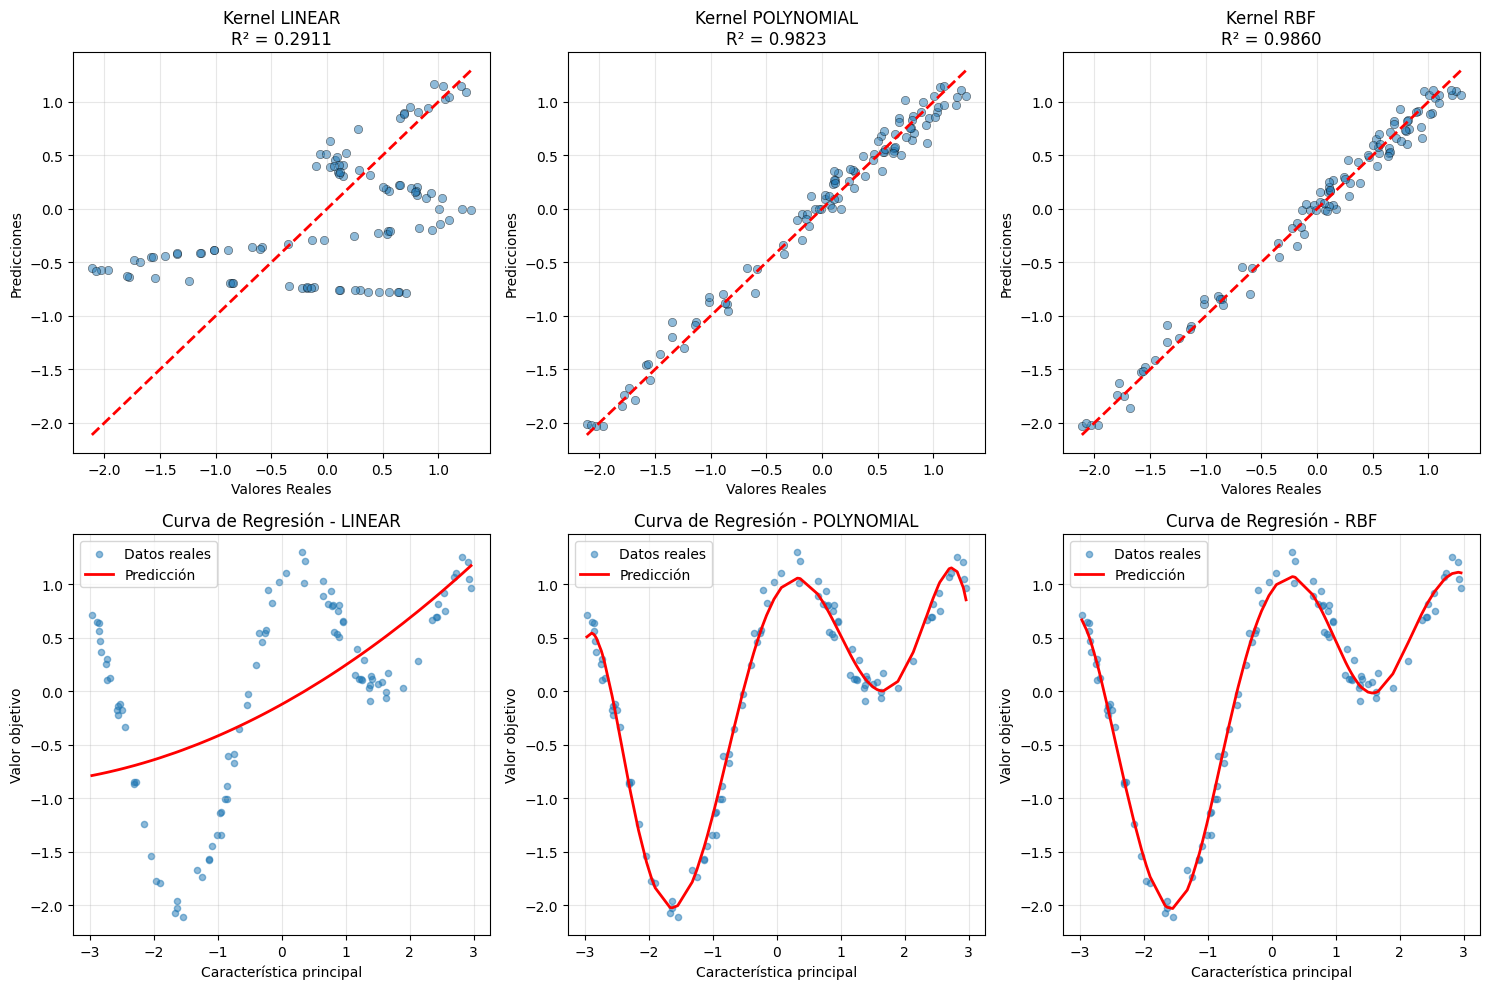


=== COMPARACIÓN DE RENDIMIENTO ===
--------------------------------------------------
Kernel       Train MSE    Test MSE     Test R²   
--------------------------------------------------
linear       0.6230       0.5880       0.2911    
polynomial   0.0147       0.0147       0.9823    
rbf          0.0105       0.0116       0.9860    
--------------------------------------------------


In [5]:
# Visualización de resultados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Ordenar datos para visualización suave
sort_idx = np.argsort(X_test.iloc[:, 0].values)

for idx, (kernel_type, result) in enumerate(custom_krr_results.items()):
    # Predicciones vs valores reales
    ax1 = axes[0, idx]
    ax1.scatter(y_test_orig, result['predictions'], alpha=0.5, edgecolors='k', linewidth=0.5)
    ax1.plot([y_test_orig.min(), y_test_orig.max()],
             [y_test_orig.min(), y_test_orig.max()], 'r--', lw=2)
    ax1.set_xlabel('Valores Reales')
    ax1.set_ylabel('Predicciones')
    ax1.set_title(f'Kernel {kernel_type.upper()}\nR² = {result["test_r2"]:.4f}')
    ax1.grid(True, alpha=0.3)

    # Curva de regresión
    ax2 = axes[1, idx]
    ax2.scatter(X_test.iloc[:, 0].values[sort_idx], y_test_orig[sort_idx],
                alpha=0.5, label='Datos reales', s=20)
    ax2.plot(X_test.iloc[:, 0].values[sort_idx], result['predictions'][sort_idx],
             'r-', label='Predicción', linewidth=2)
    ax2.set_xlabel('Característica principal')
    ax2.set_ylabel('Valor objetivo')
    ax2.set_title(f'Curva de Regresión - {kernel_type.upper()}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación de errores
print("\n=== COMPARACIÓN DE RENDIMIENTO ===")
print("-" * 50)
print(f"{'Kernel':<12} {'Train MSE':<12} {'Test MSE':<12} {'Test R²':<10}")
print("-" * 50)
for kernel_type, result in custom_krr_results.items():
    print(f"{kernel_type:<12} {result['train_mse']:<12.4f} "
          f"{result['test_mse']:<12.4f} {result['test_r2']:<10.4f}")
print("-" * 50)



# Ejecucion con metodos de SkLearn

In [ ]:
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline


models_kkr = {
    "linear": Pipeline([("scaler", StandardScaler()), ("krr", KernelRidge(alpha=0.1,kernel="linear"))]),
    "polynomial": Pipeline([("scaler", StandardScaler()), ("krr", KernelRidge(alpha=0.1, kernel='polynomial',
                                      gamma=0.5, degree=3, coef0=1))]),
    "rbf": Pipeline([("scaler", StandardScaler()), ("krr", KernelRidge(alpha=0.1, kernel='rbf', gamma=0.5))]),
}

sklearn_krr_results = {}

print("\n=== ENTRENANDO MODELOS SKLEARN KERNEL RIDGE ===")
for name, model in models_kkr.items():
    print(f"\n--- Kernel {name.upper()} ---")
    model.fit(X_train, y_train)

    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # Métricas
    train_mse = mean_squared_error(y_train, y_pred_train)
    test_mse = mean_squared_error(y_test, y_pred_test)
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)

    # Guardar resultados
    sklearn_krr_results[name] = {
        'train_mse': train_mse,
        'test_mse': test_mse,
        'train_r2': train_r2,
        'test_r2': test_r2,
        'predictions': y_pred_test,
        'model': model
    }

    print(f"Train - MSE: {train_mse:.4f}, R²: {train_r2:.4f}")
    print(f"Test  - MSE: {test_mse:.4f}, R²: {test_r2:.4f}")


=== ENTRENANDO MODELOS SKLEARN KERNEL RIDGE ===

--- Kernel LINEAR ---
Train - MSE: 0.6230, R²: 0.3689
Test  - MSE: 0.5880, R²: 0.2910

--- Kernel POLYNOMIAL ---
Train - MSE: 0.0147, R²: 0.9851
Test  - MSE: 0.0147, R²: 0.9823

--- Kernel RBF ---
Train - MSE: 0.0105, R²: 0.9894
Test  - MSE: 0.0116, R²: 0.9860


# Visualización de los resultados con SKLearn

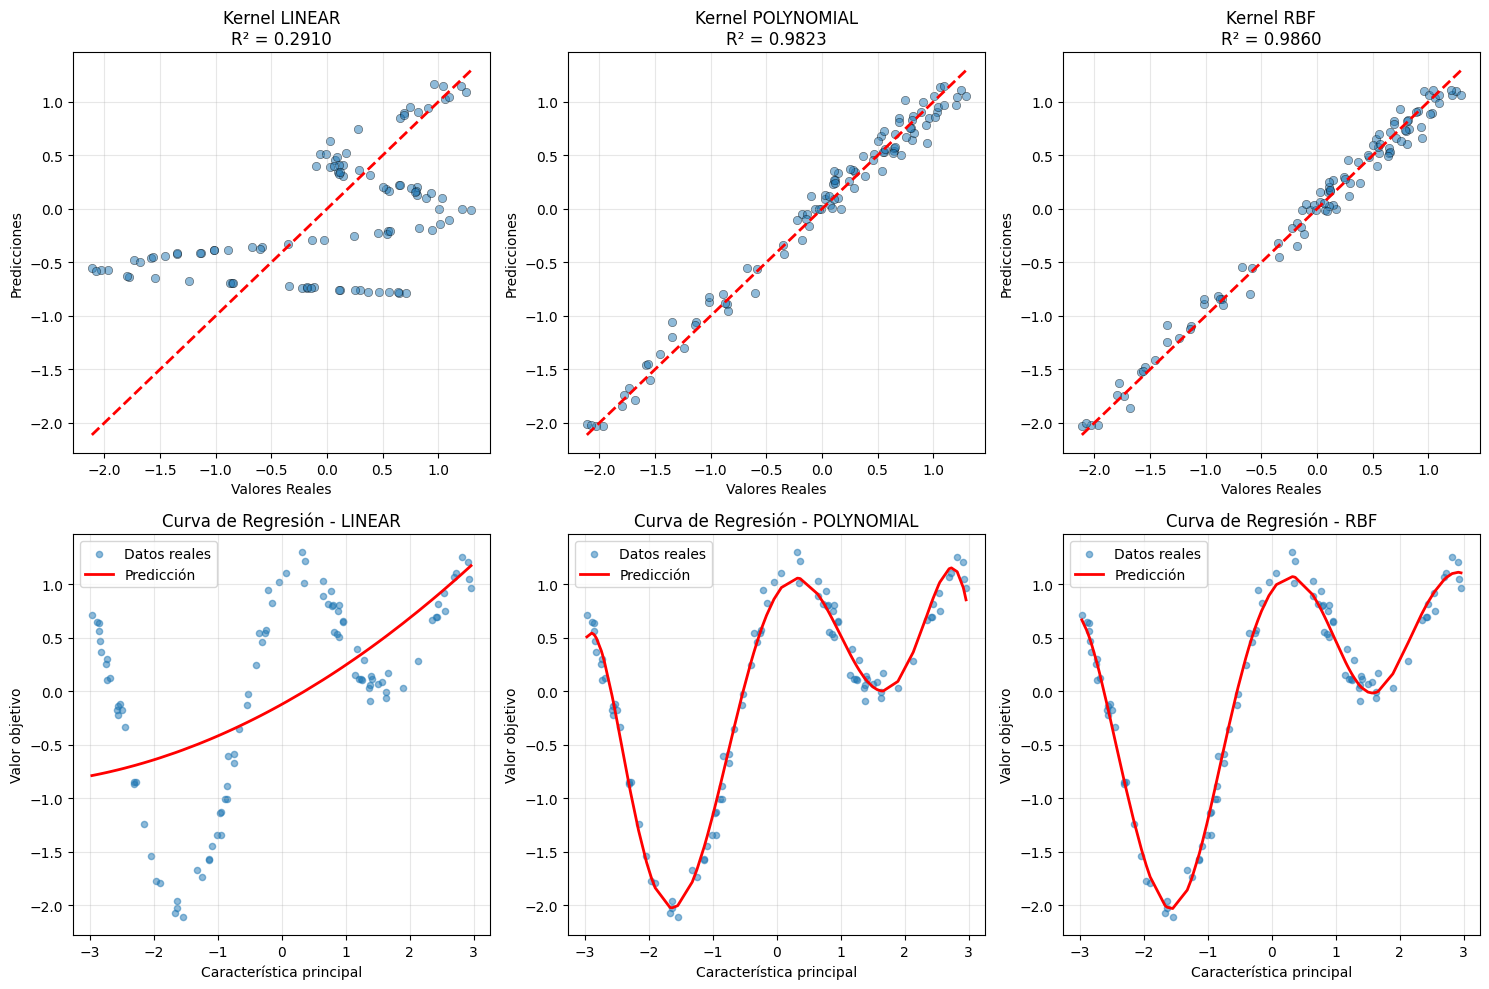


=== COMPARACIÓN DE RENDIMIENTO ===
--------------------------------------------------
Kernel       Train MSE    Test MSE     Test R²   
--------------------------------------------------
linear       0.6230       0.5880       0.2910    
polynomial   0.0147       0.0147       0.9823    
rbf          0.0105       0.0116       0.9860    
--------------------------------------------------


In [ ]:
# Visualización de resultados
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Ordenar datos para visualización suave
sort_idx = np.argsort(X_test.iloc[:, 0].values)

for idx, (kernel_type, result) in enumerate(sklearn_krr_results.items()):
    # Predicciones vs valores reales
    ax1 = axes[0, idx]
    ax1.scatter(y_test, result['predictions'], alpha=0.5, edgecolors='k', linewidth=0.5)
    ax1.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2)
    ax1.set_xlabel('Valores Reales')
    ax1.set_ylabel('Predicciones')
    ax1.set_title(f'Kernel {kernel_type.upper()}\nR² = {result["test_r2"]:.4f}')
    ax1.grid(True, alpha=0.3)

    # Curva de regresión
    ax2 = axes[1, idx]
    ax2.scatter(X_test.iloc[:, 0].values[sort_idx], y_test.values[sort_idx],
                alpha=0.5, label='Datos reales', s=20)
    ax2.plot(X_test.iloc[:, 0].values[sort_idx], result['predictions'][sort_idx],
             'r-', label='Predicción', linewidth=2)
    ax2.set_xlabel('Característica principal')
    ax2.set_ylabel('Valor objetivo')
    ax2.set_title(f'Curva de Regresión - {kernel_type.upper()}')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación de errores
print("\n=== COMPARACIÓN DE RENDIMIENTO ===")
print("-" * 50)
print(f"{'Kernel':<12} {'Train MSE':<12} {'Test MSE':<12} {'Test R²':<10}")
print("-" * 50)
for kernel_type, result in sklearn_krr_results.items():
    print(f"{kernel_type:<12} {result['train_mse']:<12.4f} "
          f"{result['test_mse']:<12.4f} {result['test_r2']:<10.4f}")
print("-" * 50)